=== SANITY CHECK (Full Rank = 19) ===
Relative L2 Error: 2.203206e-11% (Debe ser ~0%)



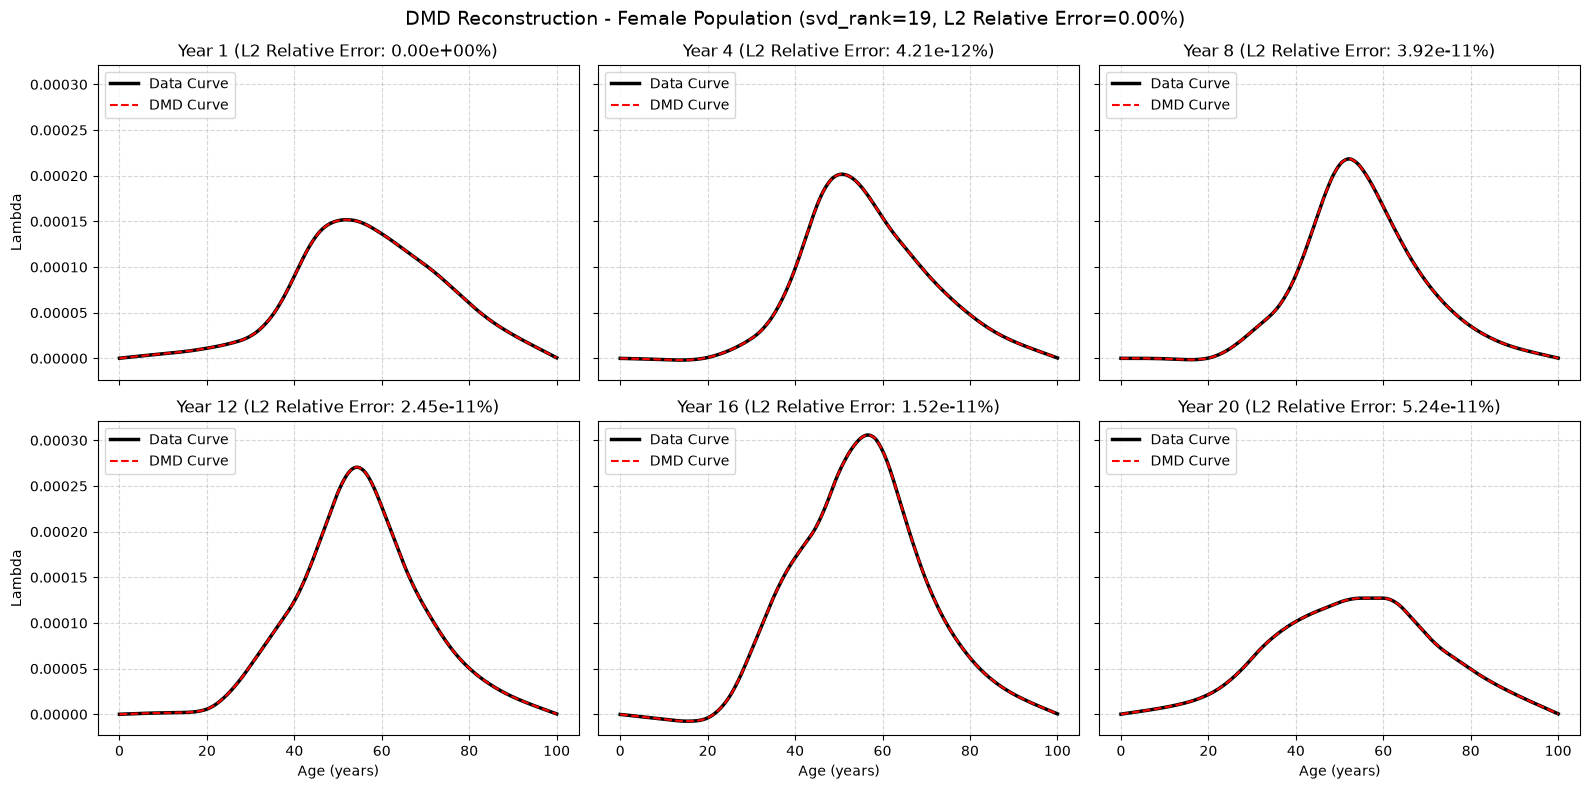

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar datos
file_path = "data/alcoholData_FemalePopulation.xls"
df_lambda = pd.read_excel(file_path, sheet_name="Lambda_by_Age_Year", index_col=0)

lambda_cols = [c for c in df_lambda.columns if 'Lambda_' in c and 'Std' not in c]
std_cols = [c for c in df_lambda.columns if 'LambdaStd_' in c]

X_mean = df_lambda[lambda_cols].values   # Matriz Media (401, 20)
X_std = df_lambda[std_cols].values      # Matriz Std (401, 20)
ages = df_lambda.index.values
n_ages, n_years = X_mean.shape

# Función DMD exacto personalizado (numéricamente estable)
def run_dmd(X, svd_rank):
    X1 = X[:, :-1]
    X2 = X[:, 1:]
    
    # SVD reducida
    U, S, Vh = np.linalg.svd(X1, full_matrices=False)
    if svd_rank is not None:
        U = U[:, :svd_rank]
        S = S[:svd_rank]
        Vh = Vh[:svd_rank, :]
    
    # Matriz A de transición completa en espacio original
    S_inv = np.diag(1.0 / S)
    A_full = X2 @ Vh.T.conj() @ S_inv @ U.T.conj()
    
    # Reconstrucción recursiva estable: x_{t+1} = A * x_t
    X_rec = np.zeros_like(X)
    X_rec[:, 0] = X[:, 0]
    for t in range(1, X.shape[1]):
        X_rec[:, t] = A_full @ X_rec[:, t-1]
        
    return X_rec, A_full

# ==============================================================================
# PASO 1: SANITY CHECK (Rango Completo = 19 en la Media)
# ==============================================================================
max_rank = n_years - 1  # 19
X_rec_full, _ = run_dmd(X_mean, svd_rank=max_rank)

err_full = np.linalg.norm(X_mean - X_rec_full) / np.linalg.norm(X_mean)
print(f"=== SANITY CHECK (Full Rank = {max_rank}) ===")
print(f"Relative L2 Error: {err_full * 100:.6e}% (Debe ser ~0%)\n")

# Reconstrucción Sanity Check (Full Rank = 19)
X_rec_full, _ = run_dmd(X_mean, svd_rank=19)

selected_years_idx = np.linspace(0, n_years - 1, 6, dtype=int)
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.flatten()

for idx, yr_idx in enumerate(selected_years_idx):
    ax = axes[idx]
    err_yr = np.linalg.norm(X_mean[:, yr_idx] - X_rec_full[:, yr_idx]) / np.linalg.norm(X_mean[:, yr_idx])
    
    ax.plot(ages, X_mean[:, yr_idx], 'k-', linewidth=2.5, label="Data Curve")
    ax.plot(ages, X_rec_full[:, yr_idx], 'r--', linewidth=1.5, label="DMD Curve")
    
    ax.set_title(f"Year {yr_idx + 1} (L2 Relative Error: {err_yr * 100:.2e}%)")
    ax.grid(True, linestyle="--", alpha=0.5)
    if idx >= 3: ax.set_xlabel("Age (years)")
    if idx % 3 == 0: ax.set_ylabel("Lambda")
    ax.legend(loc="upper left")

plt.suptitle(f"DMD Reconstruction - Female Population (svd_rank={max_rank}, L2 Relative Error={err_full*100:.2f}%)", fontsize=14)
plt.tight_layout()
plt.savefig("results/dmd/sanity_check_female.png", dpi=300)
plt.show()

=== BASELINE DETERMINISTA (svd_rank = 16) ===
Relative L2 Error: 23.71%
R-squared Score:   0.8999



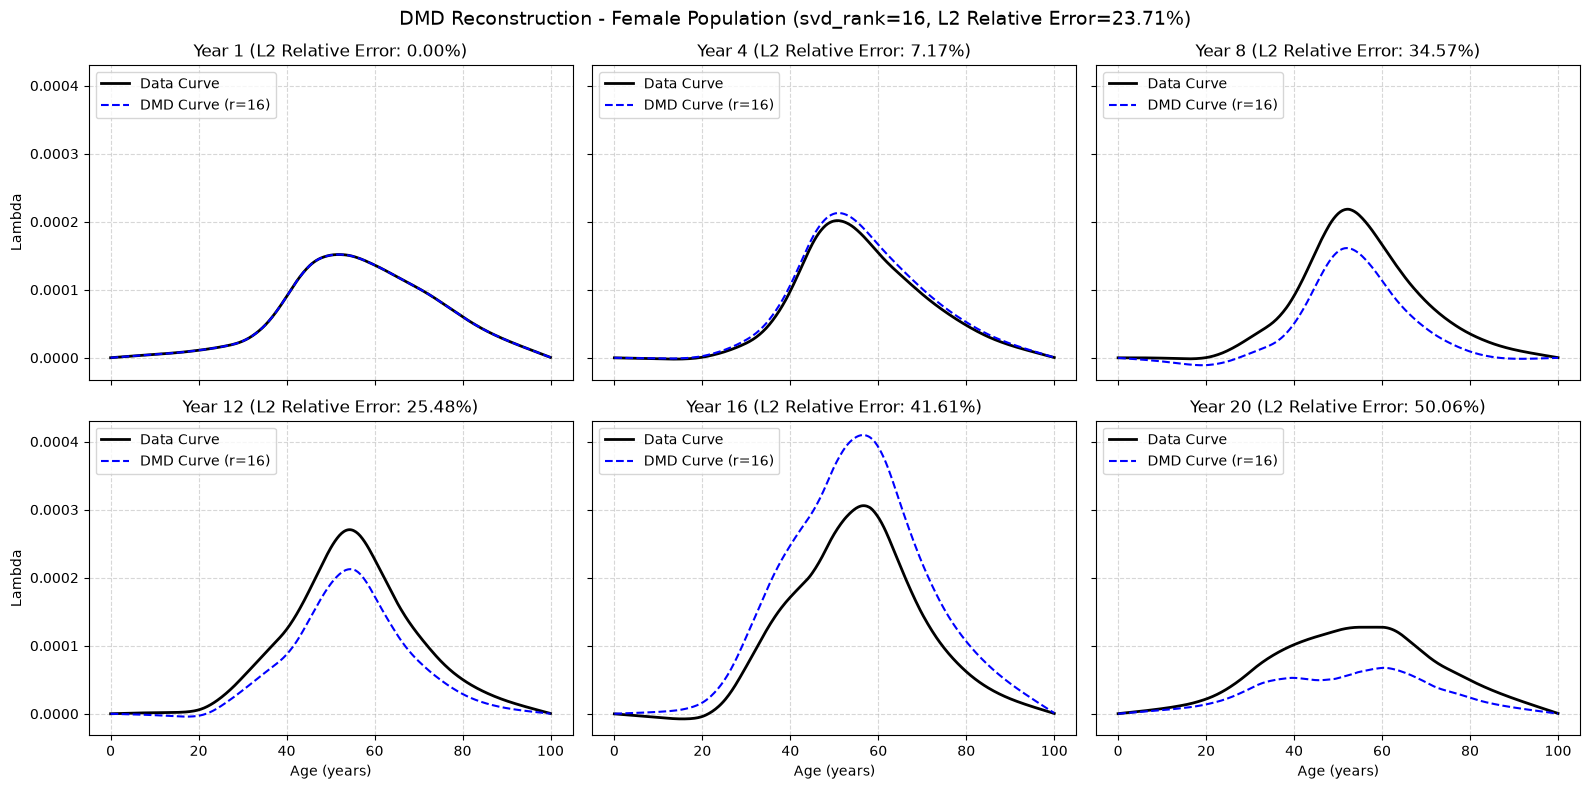

In [6]:
svd_rank = 16
X_rec_base, _ = run_dmd(X_mean, svd_rank=svd_rank)

err_base = np.linalg.norm(X_mean - X_rec_base) / np.linalg.norm(X_mean)
r2_base = 1 - (np.sum((X_mean - X_rec_base)**2) / np.sum((X_mean - np.mean(X_mean))**2))

print(f"=== BASELINE DETERMINISTA (svd_rank = {svd_rank}) ===")
print(f"Relative L2 Error: {err_base * 100:.2f}%")
print(f"R-squared Score:   {r2_base:.4f}\n")

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.flatten()

for idx, yr_idx in enumerate(selected_years_idx):
    ax = axes[idx]
    err_yr = np.linalg.norm(X_mean[:, yr_idx] - X_rec_base[:, yr_idx]) / np.linalg.norm(X_mean[:, yr_idx])
    
    ax.plot(ages, X_mean[:, yr_idx], 'k-', linewidth=2, label="Data Curve")
    ax.plot(ages, X_rec_base[:, yr_idx], 'b--', linewidth=1.5, label=f"DMD Curve (r={svd_rank})")
    
    ax.set_title(f"Year {yr_idx + 1} (L2 Relative Error: {err_yr * 100:.2f}%)")
    ax.grid(True, linestyle="--", alpha=0.5)
    if idx >= 3: ax.set_xlabel("Age (years)")
    if idx % 3 == 0: ax.set_ylabel("Lambda")
    ax.legend(loc="upper left")

plt.suptitle(f"DMD Reconstruction - Female Population (svd_rank={svd_rank}, L2 Relative Error={err_base*100:.2f}%)", fontsize=14)
plt.tight_layout()
plt.savefig(f"results/dmd/female_reconstruction_r={svd_rank}.png", dpi=300)
plt.show()

=== BASELINE RECONSTRUCTION PERFORMANCE ===
Relative L2 Error: 42.79%
R-squared Score (R2):     0.6739

=== MONTE CARLO RECONSTRUCTION PERFORMANCE (1000 sims) ===
Mean Relative Error: 36.87% (95% CI: [32.42%, 42.97%])
Mean R2 Score:       0.7554 (95% CI: [0.6697, 0.8118])



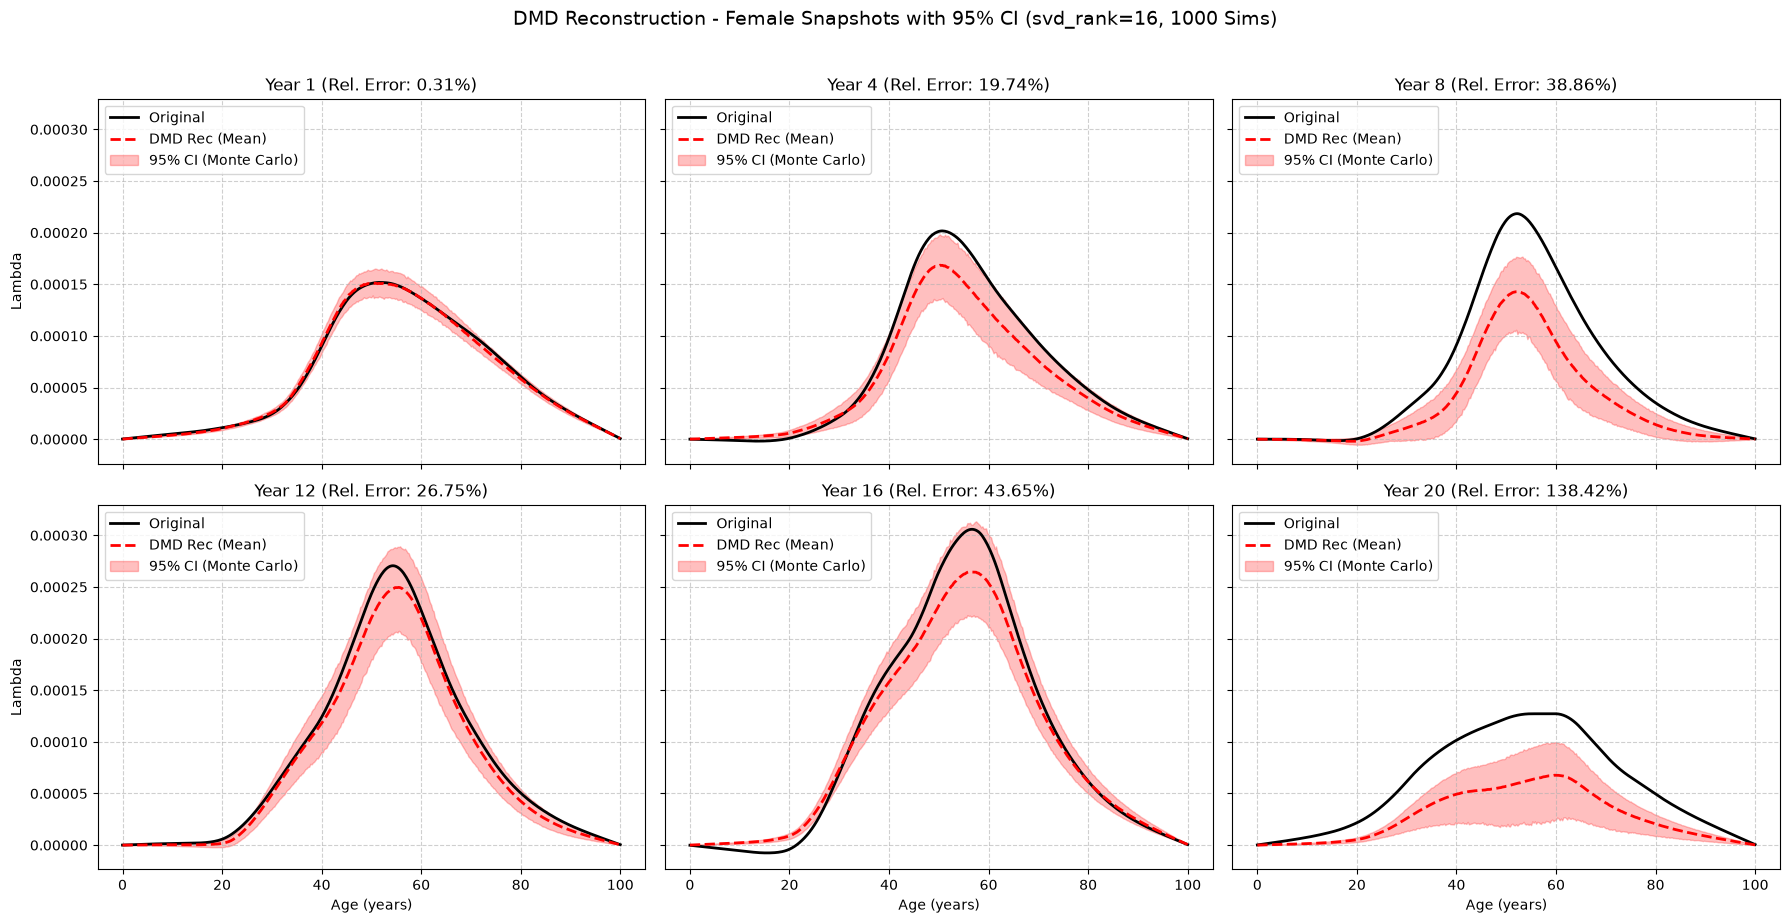

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from pydmd import DMD

# 1. Reconstrucción de la línea base con el dmd_base ajustado en Celda 1
X_rec_base = np.real(dmd_base.reconstructed_data)

# Métricas para la línea base
rel_err_base = np.linalg.norm(X_mean - X_rec_base) / np.linalg.norm(X_mean)
r2_base = 1 - (np.sum((X_mean - X_rec_base)**2) / np.sum((X_mean - np.mean(X_mean))**2))

# 2. Evaluación Monte Carlo: Matriz de Reconstrucciones (1000, n_ages, n_years)
all_reconstructions = np.zeros((n_sims, n_ages, n_years))
rel_errors = np.zeros(n_sims)
r2_scores = np.zeros(n_sims)

np.random.seed(42)  # Misma semilla para reproducir exactamente las muestras
for k in range(n_sims):
    X_sample = np.random.normal(loc=X_mean, scale=X_std)
    X_sample = np.maximum(X_sample, 0.0)

    dmd_sample = DMD(svd_rank=svd_rank, exact=True)
    dmd_sample.fit(X_sample)
    
    X_rec_sample = np.real(dmd_sample.reconstructed_data)
    
    # Guardar reconstrucción de la simulación k
    all_reconstructions[k, :, :] = X_rec_sample
    
    rel_errors[k] = np.linalg.norm(X_sample - X_rec_sample, 'fro') / np.linalg.norm(X_sample, 'fro')
    r2_scores[k] = 1 - (np.sum((X_sample - X_rec_sample)**2) / np.sum((X_sample - np.mean(X_sample))**2))

# 3. Percentiles de Reconstrucción (Intervalos de Confianza)
rec_mean = np.mean(all_reconstructions, axis=0)
rec_p025 = np.percentile(all_reconstructions, 2.5, axis=0)
rec_p975 = np.percentile(all_reconstructions, 97.5, axis=0)

# Impresión de Métricas
err_mean, err_p025, err_p975 = np.mean(rel_errors), np.percentile(rel_errors, 2.5), np.percentile(rel_errors, 97.5)
r2_mean, r2_p025, r2_p975 = np.mean(r2_scores), np.percentile(r2_scores, 2.5), np.percentile(r2_scores, 97.5)

print("=== BASELINE RECONSTRUCTION PERFORMANCE ===")
print(f"Relative L2 Error: {rel_err_base * 100:.2f}%")
print(f"R-squared Score (R2):     {r2_base:.4f}\n")

print(f"=== MONTE CARLO RECONSTRUCTION PERFORMANCE ({n_sims} sims) ===")
print(f"Mean Relative Error: {err_mean * 100:.2f}% (95% CI: [{err_p025 * 100:.2f}%, {err_p975 * 100:.2f}%])")
print(f"Mean R2 Score:       {r2_mean:.4f} (95% CI: [{r2_p025:.4f}, {r2_p975:.4f}])\n")

# 4. Gráfico Cuadrícula 2x3: Snapshots de 6 años con 95% CI
selected_years_idx = np.linspace(0, n_years - 1, 6, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True, sharey=True)
axes = axes.flatten()

for idx, yr_idx in enumerate(selected_years_idx):
    ax = axes[idx]
    
    # Error relativo del año específico en la línea base
    err_yr = np.linalg.norm(X_mean[:, yr_idx] - X_rec_base[:, yr_idx]) / np.linalg.norm(X_mean[:, yr_idx])
    
    # Curva original
    ax.plot(ages, X_mean[:, yr_idx], 'k-', linewidth=2, label="Original")
    
    # Reconstrucción promedio Monte Carlo
    ax.plot(ages, rec_mean[:, yr_idx], 'r--', linewidth=2, label="DMD Rec (Mean)")
    
    # Banda de Confianza 95%
    ax.fill_between(
        ages, 
        rec_p025[:, yr_idx], 
        rec_p975[:, yr_idx], 
        color='red', 
        alpha=0.25, 
        label="95% CI (Monte Carlo)"
    )
    
    ax.set_title(f"Year {yr_idx + 1} (Rel. Error: {err_yr * 100:.2f}%)")
    ax.grid(True, linestyle="--", alpha=0.6)
    
    # Etiquetas en bordes exteriores
    if idx >= 3:
        ax.set_xlabel("Age (years)")
    if idx % 3 == 0:
        ax.set_ylabel("Lambda")
        
    ax.legend(loc="upper left")

plt.suptitle(f"DMD Reconstruction - Female Snapshots with 95% CI (svd_rank={svd_rank}, 1000 Sims)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("results/dmd/dmd_female_reconstruction.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pydmd import HankelDMD

# 1. Load data
file_path = "data/alcoholData_FemalePopulation.xls"
df_lambda = pd.read_excel(file_path, sheet_name="Lambda_by_Age_Year", index_col=0)

lambda_cols = [c for c in df_lambda.columns if 'Lambda_' in c and 'Std' not in c]
std_cols = [c for c in df_lambda.columns if 'LambdaStd_' in c]

X_mean = df_lambda[lambda_cols].values  # Mean Matrix (401, 20)
X_std = df_lambda[std_cols].values      # Standard Deviation Matrix (401, 20)
ages = df_lambda.index.values

# 2. Initial configuration
n_sims = 1000
svd_rank = 4
d_delay = 4  # Time delay (3 years)
n_ages, n_years = X_mean.shape

# 3. HANKEL-DMD BASELINE
dmd_base = HankelDMD(svd_rank=svd_rank, d=d_delay, exact=True)
dmd_base.fit(X_mean)
# Trim the first 401 rows to project onto the physical age variable
base_modes = np.real(dmd_base.modes[:n_ages, :])
base_eigs = dmd_base.eigs

# Structures to store Monte Carlo results
all_modes = np.zeros((n_sims, n_ages, svd_rank))
all_eigs = np.zeros((n_sims, svd_rank), dtype=complex)

# 4. Monte Carlo loop
np.random.seed(42)
for k in range(n_sims):
    # Generate stochastic surface
    X_sample = np.random.normal(loc=X_mean, scale=X_std)
    X_sample = np.maximum(X_sample, 0.0)  # Truncate to >= 0

    # Fit HankelDMD to sample
    dmd = HankelDMD(svd_rank=svd_rank, d=d_delay, exact=True)
    dmd.fit(X_sample)

    # Extract modes trimmed to the 401 physical ages
    current_modes = np.real(dmd.modes[:n_ages, :])
    current_eigs = dmd.eigs

    # Match by similarity
    matched_modes = np.zeros_like(current_modes)
    matched_eigs = np.zeros_like(current_eigs)
    used_indices = set()

    for j in range(svd_rank):
        dots = [
            np.abs(np.dot(current_modes[:, m], base_modes[:, j])) if m not in used_indices else -1
            for m in range(svd_rank)
        ]
        best_m = np.argmax(dots)
        used_indices.add(best_m)

        mode_j = current_modes[:, best_m].copy()
        
        # Correct sign direction
        if np.dot(mode_j, base_modes[:, j]) < 0:
            mode_j *= -1

        matched_modes[:, j] = mode_j
        matched_eigs[j] = current_eigs[best_m]

    all_modes[k, :, :] = matched_modes
    all_eigs[k, :] = matched_eigs

# 5. Statistics (Mean and 95% Confidence Interval)
modes_mean = np.mean(all_modes, axis=0)
modes_p025 = np.percentile(all_modes, 2.5, axis=0)
modes_p975 = np.percentile(all_modes, 97.5, axis=0)

# 6. Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Hankel-DMD Spatial Modes with Confidence Bands
for i in range(svd_rank):
    axes[0].plot(ages, modes_mean[:, i], label=f"Hankel Mode {i+1}")
    axes[0].fill_between(ages, modes_p025[:, i], modes_p975[:, i], alpha=0.2)

axes[0].set_title(f"Hankel-DMD Spatial Modes (d={d_delay}, Mean ± 95% CI)")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Mode Amplitude")
axes[0].legend()
axes[0].grid(True)

# Plot 2: Hankel-DMD Monte Carlo Eigenvalue Cloud
theta = np.linspace(0, 2 * np.pi, 100)
axes[1].plot(np.cos(theta), np.sin(theta), "k--", alpha=0.5, label="Unit Circle")
axes[1].scatter(
    np.real(all_eigs.flatten()),
    np.imag(all_eigs.flatten()),
    c="red", alpha=0.15, s=10, label="Hankel Cloud (λ)"
)

axes[1].set_title(f"Hankel-DMD Eigenvalue Uncertainty (d={d_delay})")
axes[1].set_xlabel("Re(λ)")
axes[1].set_ylabel("Im(λ)")
axes[1].axis("equal")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("results/hankel_dmd_d=4/hankel_dmd_female_modes.png")
plt.show()

IndexError: index 8 is out of bounds for axis 1 with size 8

=== HANKEL-DMD BASELINE PERFORMANCE (d=8, rank=8) ===
Relative Error:        53.59%
R-squared Score (R2):  0.4883

=== MONTE CARLO HANKEL-DMD PERFORMANCE (100 sims) ===
Mean Relative Error:   50.75% (95% CI: [45.13%, 57.25%])
Mean R2 Score:         0.5368 (95% CI: [0.4131, 0.6354])



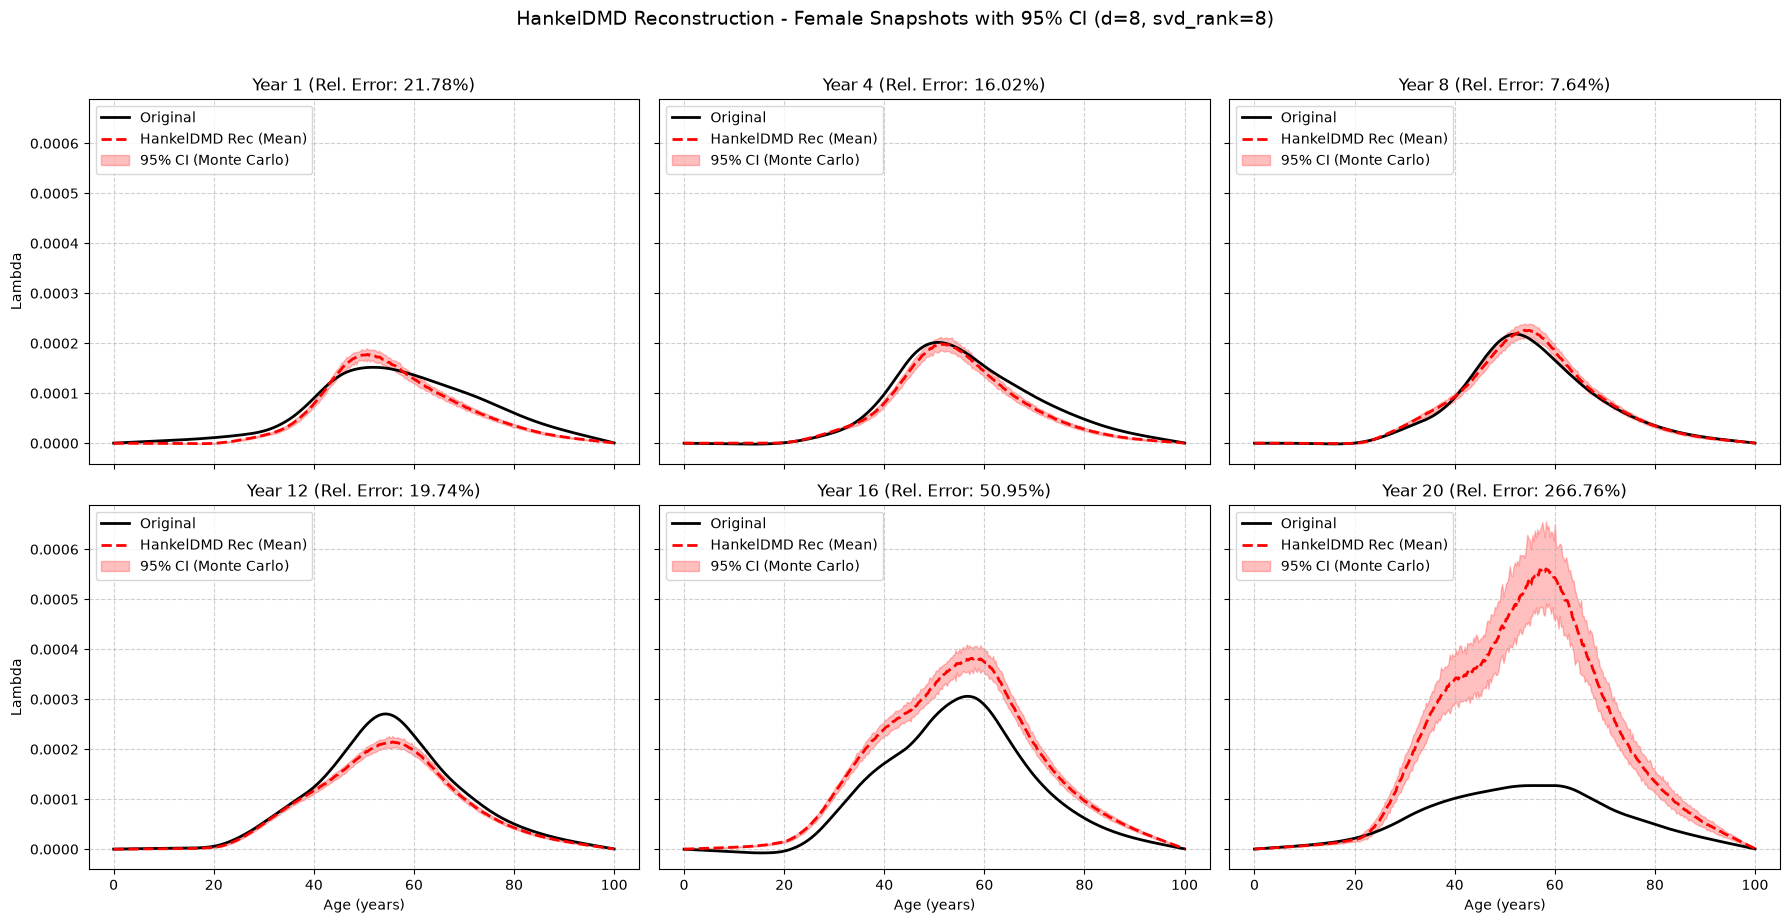

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from pydmd import HankelDMD

# 1. Reconstrucción base recortada a las edades físicas (n_ages, n_years)
X_rec_base = np.real(dmd_base.reconstructed_data)[:n_ages, :]

# Métricas para la línea base
rel_err_base = np.linalg.norm(X_mean - X_rec_base) / np.linalg.norm(X_mean)
r2_base = 1 - (np.sum((X_mean - X_rec_base)**2) / np.sum((X_mean - np.mean(X_mean))**2))

# 2. Evaluación Monte Carlo: Matriz de Reconstrucciones recortadas
all_reconstructions = np.zeros((n_sims, n_ages, n_years))
rel_errors = np.zeros(n_sims)
r2_scores = np.zeros(n_sims)

np.random.seed(42)  # Misma semilla para reproducir exactamente las muestras
for k in range(n_sims):
    X_sample = np.random.normal(loc=X_mean, scale=X_std)
    X_sample = np.maximum(X_sample, 0.0)

    dmd_sample = HankelDMD(svd_rank=svd_rank, d=d_delay, exact=True)
    dmd_sample.fit(X_sample)
    
    # Recortar a dimensión física n_ages
    X_rec_sample = np.real(dmd_sample.reconstructed_data)[:n_ages, :]
    
    all_reconstructions[k, :, :] = X_rec_sample
    
    rel_errors[k] = np.linalg.norm(X_sample - X_rec_sample) / np.linalg.norm(X_sample)
    r2_scores[k] = 1 - (np.sum((X_sample - X_rec_sample)**2) / np.sum((X_sample - np.mean(X_sample))**2))

# 3. Percentiles de Reconstrucción (Intervalos de Confianza)
rec_mean = np.mean(all_reconstructions, axis=0)
rec_p025 = np.percentile(all_reconstructions, 2.5, axis=0)
rec_p975 = np.percentile(all_reconstructions, 97.5, axis=0)

# Impresión de Métricas
err_mean, err_p025, err_p975 = np.mean(rel_errors), np.percentile(rel_errors, 2.5), np.percentile(rel_errors, 97.5)
r2_mean, r2_p025, r2_p975 = np.mean(r2_scores), np.percentile(r2_scores, 2.5), np.percentile(r2_scores, 97.5)

print(f"=== HANKEL-DMD BASELINE PERFORMANCE (d={d_delay}, rank={svd_rank}) ===")
print(f"Relative Error:        {rel_err_base * 100:.2f}%")
print(f"R-squared Score (R2):  {r2_base:.4f}\n")

print(f"=== MONTE CARLO HANKEL-DMD PERFORMANCE ({n_sims} sims) ===")
print(f"Mean Relative Error:   {err_mean * 100:.2f}% (95% CI: [{err_p025 * 100:.2f}%, {err_p975 * 100:.2f}%])")
print(f"Mean R2 Score:         {r2_mean:.4f} (95% CI: [{r2_p025:.4f}, {r2_p975:.4f}])\n")

# 4. Gráfico Cuadrícula 2x3: Snapshots de 6 años con 95% CI
selected_years_idx = np.linspace(0, n_years - 1, 6, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True, sharey=True)
axes = axes.flatten()

for idx, yr_idx in enumerate(selected_years_idx):
    ax = axes[idx]
    
    # Error relativo L2 específico del año
    err_yr = np.linalg.norm(X_mean[:, yr_idx] - X_rec_base[:, yr_idx]) / np.linalg.norm(X_mean[:, yr_idx])
    
    ax.plot(ages, X_mean[:, yr_idx], 'k-', linewidth=2, label="Original")
    ax.plot(ages, rec_mean[:, yr_idx], 'r--', linewidth=2, label="HankelDMD Rec (Mean)")
    
    ax.fill_between(
        ages, 
        rec_p025[:, yr_idx], 
        rec_p975[:, yr_idx], 
        color='red', 
        alpha=0.25, 
        label="95% CI (Monte Carlo)"
    )
    
    ax.set_title(f"Year {yr_idx + 1} (Rel. Error: {err_yr * 100:.2f}%)")
    ax.grid(True, linestyle="--", alpha=0.6)
    
    if idx >= 3:
        ax.set_xlabel("Age (years)")
    if idx % 3 == 0:
        ax.set_ylabel("Lambda")
        
    ax.legend(loc="upper left")

plt.suptitle(f"HankelDMD Reconstruction - Female Snapshots with 95% CI (d={d_delay}, svd_rank={svd_rank})", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("results/hankel_dmd_d=4/hankel_dmd_female_reconstruction.png", dpi=300, bbox_inches="tight")
plt.show()

Running 1000 Monte Carlo simulations in parallel...


Monte Carlo Progress: 100%|██████████| 100/100 [00:07<00:00, 13.21it/s]


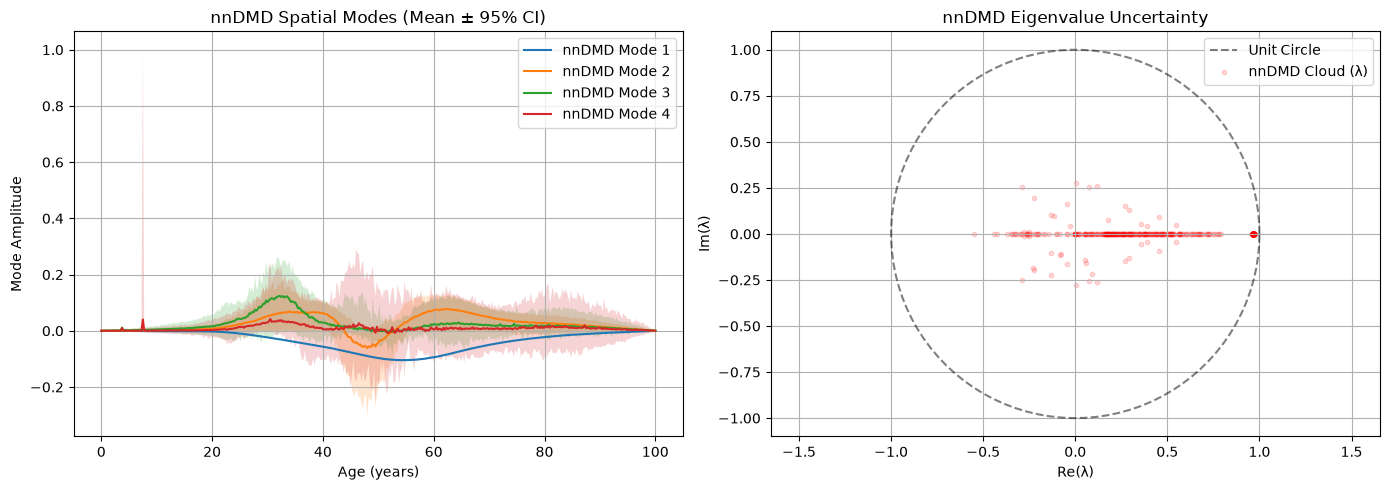

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import nnls
from joblib import Parallel, delayed
from tqdm import tqdm

# 1. Load data
file_path = "data/alcoholData_FemalePopulation.xls"
df_lambda = pd.read_excel(file_path, sheet_name="Lambda_by_Age_Year", index_col=0)

lambda_cols = [c for c in df_lambda.columns if 'Lambda_' in c and 'Std' not in c]
std_cols = [c for c in df_lambda.columns if 'LambdaStd_' in c]

X_mean = df_lambda[lambda_cols].values  # Mean Matrix (401, 20)
X_std = df_lambda[std_cols].values      # Standard Deviation Matrix (401, 20)
ages = df_lambda.index.values

# 2. Initial configuration
n_sims = 100
svd_rank = 4
n_ages, n_years = X_mean.shape

# Helper function to fit nnDMD
def fit_nndmd(X_data, r=4):
    X1 = X_data[:, :-1]
    X2 = X_data[:, 1:]
    n = X_data.shape[0]
    
    A_nn = np.zeros((n, n))
    X1_T = X1.T
    for i in range(n):
        sol, _ = nnls(X1_T, X2[i, :])
        A_nn[i, :] = sol
        
    all_eigs, all_modes = np.linalg.eig(A_nn)
    idx = np.argsort(np.abs(all_eigs))[::-1][:r]
    return all_eigs[idx], all_modes[:, idx]

# 3. BASELINE nnDMD (Calculated outside the loop)
base_eigs, base_modes_complex = fit_nndmd(X_mean, r=svd_rank)
base_modes = np.real(base_modes_complex)

# 4. Worker function for a single simulation (for parallel execution)
def run_single_simulation(k, X_mean, X_std, base_modes, svd_rank):
    # Independent seed per thread to ensure parallel randomness
    np.random.seed(42 + k)
    
    # Generate stochastic surface N(mu, sigma)
    X_sample = np.random.normal(loc=X_mean, scale=X_std)
    X_sample = np.maximum(X_sample, 0.0)  # Truncate to >= 0

    # Fit nnDMD
    current_eigs, current_modes_complex = fit_nndmd(X_sample, r=svd_rank)
    current_modes = np.real(current_modes_complex)

    # Match by similarity (permutation and sign alignment)
    matched_modes = np.zeros_like(current_modes)
    matched_eigs = np.zeros_like(current_eigs)
    used_indices = set()

    for j in range(svd_rank):
        dots = [
            np.abs(np.dot(current_modes[:, m], base_modes[:, j])) if m not in used_indices else -1
            for m in range(svd_rank)
        ]
        best_m = np.argmax(dots)
        used_indices.add(best_m)

        mode_j = current_modes[:, best_m].copy()
        if np.dot(mode_j, base_modes[:, j]) < 0:
            mode_j *= -1

        matched_modes[:, j] = mode_j
        matched_eigs[j] = current_eigs[best_m]

    return matched_modes, matched_eigs

# 5. Parallel Execution with Progress Bar (tqdm)
print("Running 1000 Monte Carlo simulations in parallel...")
results = Parallel(n_jobs=-1)(
    delayed(run_single_simulation)(k, X_mean, X_std, base_modes, svd_rank)
    for k in tqdm(range(n_sims), desc="Monte Carlo Progress")
)

# 6. Reconstruct global arrays
all_modes = np.zeros((n_sims, n_ages, svd_rank))
all_eigs = np.zeros((n_sims, svd_rank), dtype=complex)

for k, (m_modes, m_eigs) in enumerate(results):
    all_modes[k, :, :] = m_modes
    all_eigs[k, :] = m_eigs

# 7. Summary statistics (Mean and 95% Confidence Interval)
modes_mean = np.mean(all_modes, axis=0)
modes_p025 = np.percentile(all_modes, 2.5, axis=0)
modes_p975 = np.percentile(all_modes, 97.5, axis=0)

# 8. Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: nnDMD Spatial Modes
for i in range(svd_rank):
    axes[0].plot(ages, modes_mean[:, i], label=f"nnDMD Mode {i+1}")
    axes[0].fill_between(ages, modes_p025[:, i], modes_p975[:, i], alpha=0.2)

axes[0].set_title("nnDMD Spatial Modes (Mean ± 95% CI)")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Mode Amplitude")
axes[0].legend()
axes[0].grid(True)

# Plot 2: nnDMD Eigenvalue Cloud
theta = np.linspace(0, 2 * np.pi, 100)
axes[1].plot(np.cos(theta), np.sin(theta), "k--", alpha=0.5, label="Unit Circle")
axes[1].scatter(
    np.real(all_eigs.flatten()),
    np.imag(all_eigs.flatten()),
    c="red", alpha=0.15, s=10, label="nnDMD Cloud (λ)"
)

axes[1].set_title("nnDMD Eigenvalue Uncertainty")
axes[1].set_xlabel("Re(λ)")
axes[1].set_ylabel("Im(λ)")
axes[1].axis("equal")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("results/nn_dmd/nn_dmd_female_modes.png")
plt.show()

Evaluando reconstrucciones de Monte Carlo en paralelo...


Reconstruction Progress: 100%|██████████| 100/100 [00:02<00:00, 37.29it/s]



=== BASELINE nnDMD PERFORMANCE ===
Relative L2 Error:     62.38%
R-squared Score (R2):  0.3068

=== MONTE CARLO nnDMD PERFORMANCE (100 sims) ===
Mean Relative Error:   60.35% (95% CI: [57.87%, 62.99%])
Mean R2 Score:         0.3478 (95% CI: [0.2898, 0.4006])



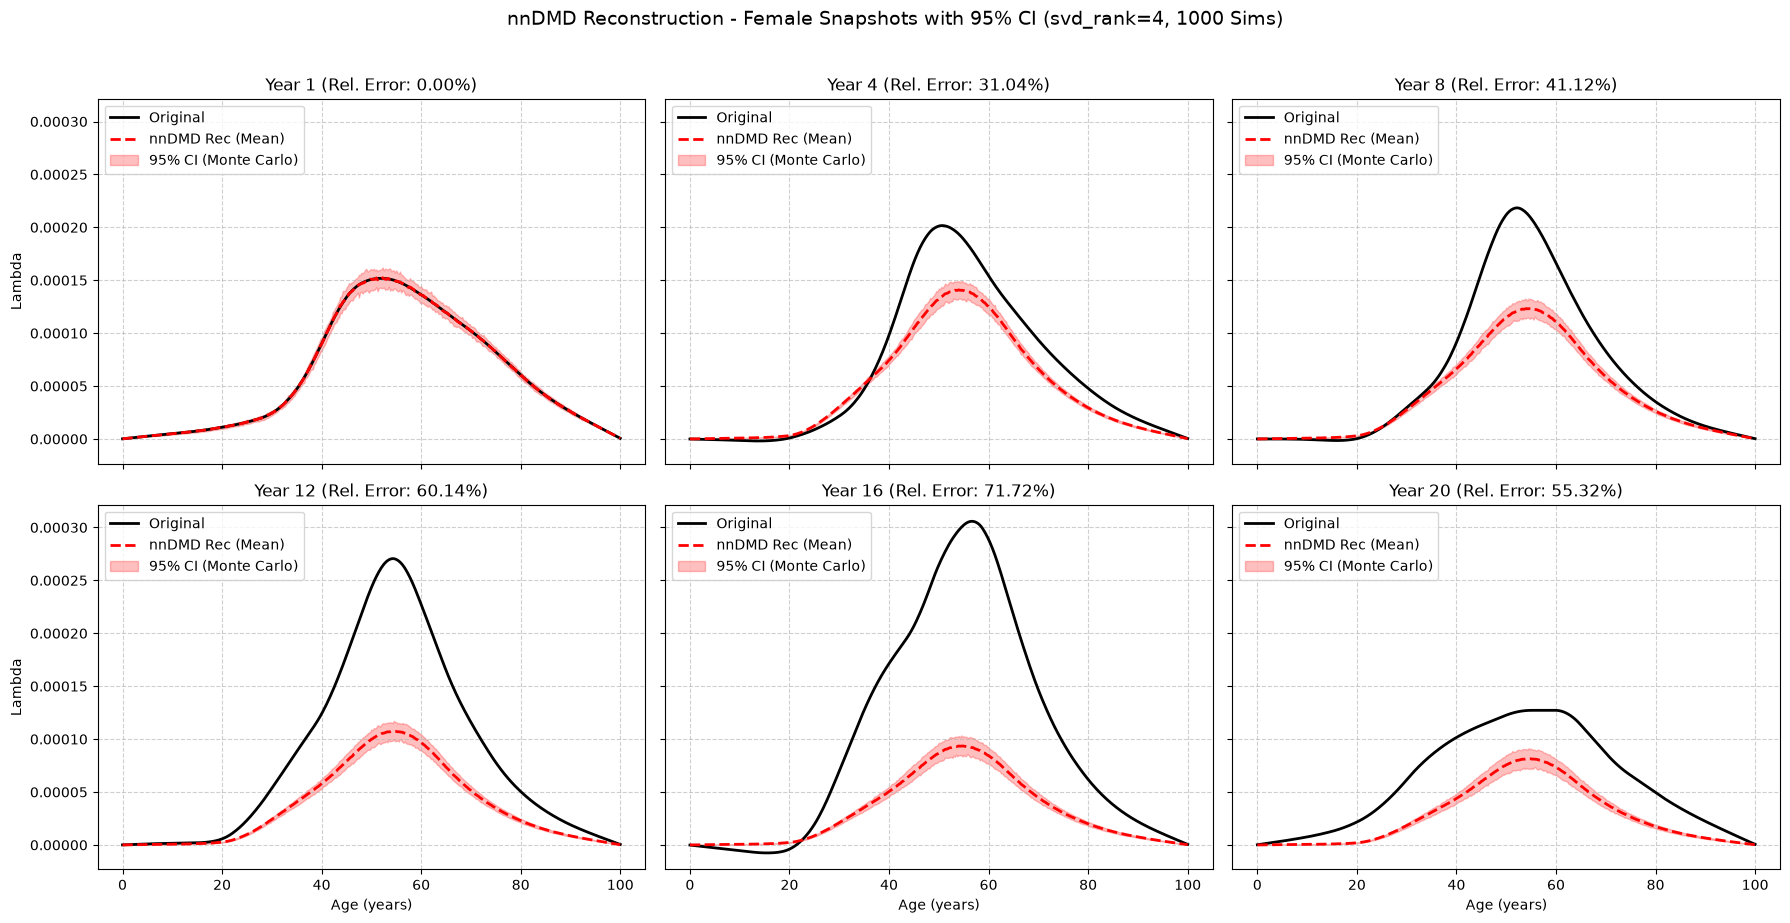

In [6]:
# ==========================================
# CELDA 2: Reconstrucción A_nn, Errores y Gráfica 2x3 con CI (nnDMD)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import nnls

# Helper function para obtener A_nn y la matriz de reconstrucción completa (n_ages, n_years)
def reconstruct_nndmd(X_data):
    X1 = X_data[:, :-1]
    X2 = X_data[:, 1:]
    n, n_t = X_data.shape
    
    A_nn = np.zeros((n, n))
    X1_T = X1.T
    for i in range(n):
        sol, _ = nnls(X1_T, X2[i, :])
        A_nn[i, :] = sol
        
    # Reconstrucción temporal: X_rec[:, t] = (A_nn^t) @ X_data[:, 0]
    X_rec = np.zeros_like(X_data)
    X_rec[:, 0] = X_data[:, 0]
    
    curr_state = X_data[:, 0]
    for t in range(1, n_t):
        curr_state = A_nn @ curr_state
        X_rec[:, t] = curr_state
        
    return X_rec

# 1. Reconstrucción de la Línea Base
X_rec_base = reconstruct_nndmd(X_mean)

# Métricas L2 y R2 para la línea base
rel_err_base = np.linalg.norm(X_mean - X_rec_base) / np.linalg.norm(X_mean)
r2_base = 1 - (np.sum((X_mean - X_rec_base)**2) / np.sum((X_mean - np.mean(X_mean))**2))

# 2. Evaluación Monte Carlo de Reconstrucciones en Paralelo
def run_mc_reconstruction(k, X_mean, X_std):
    np.random.seed(42 + k)
    X_sample = np.random.normal(loc=X_mean, scale=X_std)
    X_sample = np.maximum(X_sample, 0.0)
    
    X_rec_sample = reconstruct_nndmd(X_sample)
    
    err_k = np.linalg.norm(X_sample - X_rec_sample) / np.linalg.norm(X_sample)
    r2_k = 1 - (np.sum((X_sample - X_rec_sample)**2) / np.sum((X_sample - np.mean(X_sample))**2))
    
    return X_rec_sample, err_k, r2_k

print("Evaluando reconstrucciones de Monte Carlo en paralelo...")
mc_results = Parallel(n_jobs=-1)(
    delayed(run_mc_reconstruction)(k, X_mean, X_std)
    for k in tqdm(range(n_sims), desc="Reconstruction Progress")
)

# 3. Estructurar Resultados y Intervalos de Confianza
all_reconstructions = np.zeros((n_sims, n_ages, n_years))
rel_errors = np.zeros(n_sims)
r2_scores = np.zeros(n_sims)

for k, (X_rec_k, err_k, r2_k) in enumerate(mc_results):
    all_reconstructions[k, :, :] = X_rec_k
    rel_errors[k] = err_k
    r2_scores[k] = r2_k

rec_mean = np.mean(all_reconstructions, axis=0)
rec_p025 = np.percentile(all_reconstructions, 2.5, axis=0)
rec_p975 = np.percentile(all_reconstructions, 97.5, axis=0)

# Impresión de Métricas
err_mean, err_p025, err_p975 = np.mean(rel_errors), np.percentile(rel_errors, 2.5), np.percentile(rel_errors, 97.5)
r2_mean, r2_p025, r2_p975 = np.mean(r2_scores), np.percentile(r2_scores, 2.5), np.percentile(r2_scores, 97.5)

print(f"\n=== BASELINE nnDMD PERFORMANCE ===")
print(f"Relative L2 Error:     {rel_err_base * 100:.2f}%")
print(f"R-squared Score (R2):  {r2_base:.4f}\n")

print(f"=== MONTE CARLO nnDMD PERFORMANCE ({n_sims} sims) ===")
print(f"Mean Relative Error:   {err_mean * 100:.2f}% (95% CI: [{err_p025 * 100:.2f}%, {err_p975 * 100:.2f}%])")
print(f"Mean R2 Score:         {r2_mean:.4f} (95% CI: [{r2_p025:.4f}, {r2_p975:.4f}])\n")

# 4. Gráfico Cuadrícula 2x3: Snapshots de 6 años con 95% CI
selected_years_idx = np.linspace(0, n_years - 1, 6, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True, sharey=True)
axes = axes.flatten()

for idx, yr_idx in enumerate(selected_years_idx):
    ax = axes[idx]
    
    # Error relativo L2 específico del año en la línea base
    err_yr = np.linalg.norm(X_mean[:, yr_idx] - X_rec_base[:, yr_idx]) / np.linalg.norm(X_mean[:, yr_idx])
    
    # Curva original
    ax.plot(ages, X_mean[:, yr_idx], 'k-', linewidth=2, label="Original")
    
    # Reconstrucción promedio Monte Carlo
    ax.plot(ages, rec_mean[:, yr_idx], 'r--', linewidth=2, label="nnDMD Rec (Mean)")
    
    # Banda de Confianza 95%
    ax.fill_between(
        ages, 
        rec_p025[:, yr_idx], 
        rec_p975[:, yr_idx], 
        color='red', 
        alpha=0.25, 
        label="95% CI (Monte Carlo)"
    )
    
    ax.set_title(f"Year {yr_idx + 1} (Rel. Error: {err_yr * 100:.2f}%)")
    ax.grid(True, linestyle="--", alpha=0.6)
    
    # Etiquetas en bordes exteriores
    if idx >= 3:
        ax.set_xlabel("Age (years)")
    if idx % 3 == 0:
        ax.set_ylabel("Lambda")
        
    ax.legend(loc="upper left")

plt.suptitle(f"nnDMD Reconstruction - Female Snapshots with 95% CI (svd_rank={svd_rank}, 1000 Sims)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("results/nn_dmd/nn_dmd_female_reconstruction.png", dpi=300, bbox_inches="tight")
plt.show()